In [70]:
import kagglehub
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
import os
from sklearn.model_selection import train_test_split
path = str(kagglehub.dataset_download("icebearogo/fruit-classification-dataset")) + "/Fruit_dataset"
print("Path to dataset files:", path)
csv_path = f"{path}/train.csv"
df = pd.read_csv(csv_path)

print(df.head())

# load csv
train_df = pd.read_csv(f"{path}/train.csv")
val_df = pd.read_csv(f"{path}/val.csv")
test_df = pd.read_csv(f"{path}/test.csv")


def load_split_grayscale(csv_df, base_path, size=(64,64)):
    images, labels = [], []
    for _, row in csv_df.iterrows():
        fname = row["image:FILE"].replace("train/", "train1/").replace("val/", "val1/").replace("test/", "test1/").lstrip("/\\")
        file  = os.path.join(base_path, fname)

        img = load_img(file, target_size=size, color_mode='grayscale')  # convert to grayscale
        arr = img_to_array(img) / 255.0  # normalize to [0,1]
        images.append(arr.flatten())
        labels.append(row["category"])
    
    return np.array(images), np.array(labels)

# usage
X_train, y_train = load_split_grayscale(train_df, path)
X_val, y_val     = load_split_grayscale(val_df, path)



print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Unique train labels:", np.unique(y_train))
print("Unique val labels:", np.unique(y_val))
print("Unique test labels:", np.unique(y_test))



Path to dataset files: /home/systems/.cache/kagglehub/datasets/icebearogo/fruit-classification-dataset/versions/1/Fruit_dataset
               image:FILE  category
0   train/oil_palm/57.jpg         0
1  train/oil_palm/881.jpg         0
2  train/oil_palm/450.jpg         0
3   train/oil_palm/28.jpg         0
4   train/oil_palm/62.jpg         0
Train: (40000, 4096) Val: (5000, 4096) Test: (5000, 3072)
Unique train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
Unique val labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82

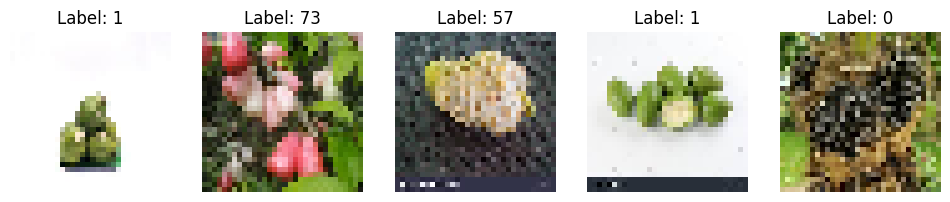

In [61]:
import random
plt.figure(figsize=(12,3))
for i, idx in enumerate(random.sample(range(len(images_vis)), 5)):
    plt.subplot(1, 5, i+1)
    plt.imshow(images_vis[idx])
    plt.title(f"Label: {y[idx]}")
    plt.axis('off')
plt.show()


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)

# Train only once
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_pca, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [64]:
from sklearn.metrics import classification_report, confusion_matrix

# Train performance (use PCA features)
print("Train Accuracy:", clf.score(X_train_pca, y_train))

# Validation performance (also use PCA features)
X_val_pca = pca.transform(X_val)  # make sure you transform validation set
val_acc = clf.score(X_val_pca, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

y_pred = clf.predict(X_val_pca)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# If you want to *see* test predictions:
#X_test_pca = pca.transform(X_test)  # transform test set too
#test_preds = clf.predict(X_test_pca)
#print("Sample predictions on Kaggle test set:", test_preds[:20])


Train Accuracy: 0.08255
Validation Accuracy: 0.0546
Confusion Matrix:
 [[0 0 1 ... 1 0 0]
 [0 1 1 ... 1 0 1]
 [0 1 3 ... 0 0 1]
 ...
 [0 0 0 ... 6 0 0]
 [0 0 0 ... 0 1 0]
 [0 1 0 ... 1 0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.05      0.02      0.03        50
           2       0.06      0.06      0.06        50
           3       0.08      0.04      0.05        50
           4       0.04      0.02      0.03        50
           5       0.00      0.00      0.00        50
           6       0.10      0.10      0.10        50
           7       0.03      0.04      0.04        50
           8       0.00      0.00      0.00        50
           9       0.00      0.00      0.00        50
          10       0.00      0.00      0.00        50
          11       0.02      0.02      0.02        50
          12       0.09      0.16      0.11        50
          13       0.10    

In [72]:
# import support vector classification model
from sklearn.svm import SVC

# Create a SVM model
model = SVC()
# Train the SVM model
model.fit(X_train_pca, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [73]:
# Make predictions
#y_pred = model.predict(X_test)
from sklearn import metrics

print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred, average = 'weighted'))
print("Recall:",metrics.recall_score(y_test, y_pred, average = 'weighted'))
print("F1-score:",metrics.f1_score(y_test, y_pred, average = 'weighted'))
print(classification_report(y_test, y_pred, ))

Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1-score: 0.0
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00    5000.0
           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00       0.0
           6       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00       0.0
           8       0.00      0.00      0.00       0.0
           9       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       0.0
          12       0.00      0.00      0.00       0.0
          13       0.00      0.00      0.00       0.0
          14       0.00      0.00      0.00       0.0
          15       0.00   

/media/systems/Data/Uni/(PRML) - Pattern Recognition and Machine Learning/PRML/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/systems/Data/Uni/(PRML) - Pattern Recognition and Machine Learning/PRML/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/systems/Data/Uni/(PRML) - Pattern Recognition and Machine Learning/PRML/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels w